In [25]:
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

In [104]:
from Elsa_transformer import build_arrays, split_by_person,train_elsa_transformer,plot_baseline_hazard

In [106]:
importlib.reload(sys.modules['ELSA_baselines_CoxPH'])

from ELSA_baselines_CoxPH import landmark_data, transformer_score,compare_at_landmark,plot_comparison, compare_sweep

In [78]:
path_to_file = "C:/Users/dinab/Desktop/PhD Projects/Ensemble methods/GitHub_App/medicaljourneys/ELSA data/elsa_long_agegrid.csv"

EVENTS = ["arthritis","asthma_respir","cancer","cataract","cvd","diabetes",
          "hip_replacement","hypertension","mental_health","neuro",
          "osteoporosis","stroke","died"]

STATIC = ["sex","edu","wealth","bmi","edu_miss","wealth_miss","bmi_miss",
          "child_n","child_asthma_respir","child_epilepsy","child_psych",
          "child_bones","child_diabetes","child_heart","child_cancer"]



In [80]:
arr = build_arrays(path_to_file, EVENTS, STATIC)

n=15137  T=10  p=28  K=13  age bins=20
events in risk set: 987663 person-bin-events at risk, 18865 observed


In [82]:
import numpy as np
L = arr["length"].numpy()
print(np.bincount(L), "median", np.median(L))

k = arr["events"].index("died")
print("deaths:", int((arr["Y"][:, :, k] * arr["R"][:, :, k]).sum()))

[   0  168 1295 1832 1799 1584 2420 1448  999 2946  646] median 6.0
deaths: 1378


C:\Users\dinab\anaconda3\envs\studio1\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


alpha initialised: baseline hazard 1.86e-05 - 1.65e-01, overall rate 0.0191
null loss (constant per-event rate): train 0.08876  test 0.08889
epoch   1  lr 1.02e-04  train 0.08971  test 0.08604
epoch   6  lr 2.98e-04  train 0.08619  test 0.08435
epoch  11  lr 2.86e-04  train 0.08467  test 0.08364
epoch  16  lr 2.63e-04  train 0.08413  test 0.08335
epoch  21  lr 2.32e-04  train 0.08398  test 0.08324
epoch  26  lr 1.95e-04  train 0.08448  test 0.08386
epoch  31  lr 1.54e-04  train 0.08570  test 0.08419
epoch  34  lr 1.29e-04  train 0.08746  test 0.08488   [early stop]


<Axes: title={'center': 'Age-specific baseline hazard (alpha)'}, xlabel='age', ylabel='baseline hazard per 2y'>

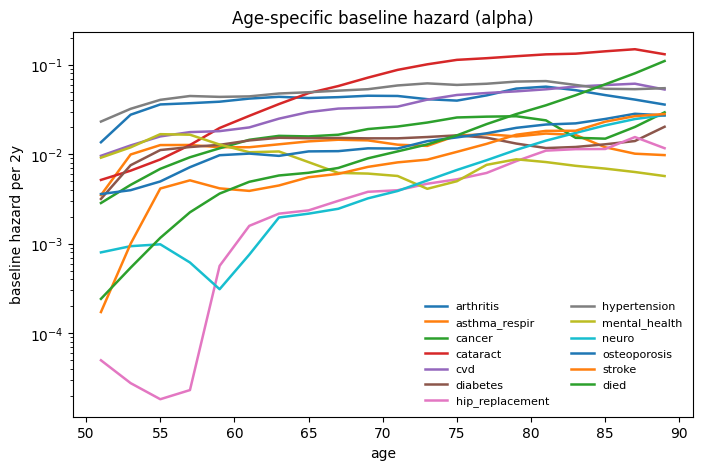

In [84]:
tr, te = split_by_person(arr, frac=0.7, seed=0)
model = train_elsa_transformer(tr, te, epochs=60, lam_smooth=1e-2)
plot_baseline_hazard(model, EVENTS, age_min=50, bin_width=2)

In [92]:
cindex_at_landmark(model, te, landmark_bin=10, horizon_bins=5, events=EVENTS)

,n_eligible,n_events,cindex
event,,,
arthritis,987,140,0.648
asthma_respir,1378,80,0.663
cancer,1495,115,0.560
cataract,1298,435,0.601
cvd,1283,190,0.613
diabetes,1460,75,0.659
hypertension,903,166,0.647
mental_health,1506,33,0.613
neuro,1632,36,0.654


In [112]:
r = compare_at_landmark(model, tr, te, landmark_bin=10, horizon_bins=5,
                        events=EVENTS, feature_names=arr["feature_names"])
print(r)

sweep = compare_sweep(model, tr, te, [2, 5, 8, 11, 14], 5,
                      EVENTS, arr["feature_names"])


               n_eligible  n_events  cox_baseline  cox_history  transformer  \
event                                                                         
arthritis             987       140         0.604        0.598        0.648   
asthma_respir        1378        80         0.576        0.603        0.663   
cancer               1495       115         0.606        0.574        0.560   
cataract             1298       435         0.568        0.588        0.601   
cvd                  1283       190         0.515        0.581        0.613   
diabetes             1460        75         0.648        0.637        0.659   
hypertension          903       166         0.582        0.607        0.647   
mental_health        1506        33         0.542        0.559        0.613   
neuro                1632        36         0.662        0.689        0.654   
osteoporosis         1563       104         0.623        0.646        0.692   
stroke               1579        63         0.528   

C:\Users\dinab\AppData\Local\Temp\ipykernel_25896\2361603257.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plot_comparison(sweep).show()


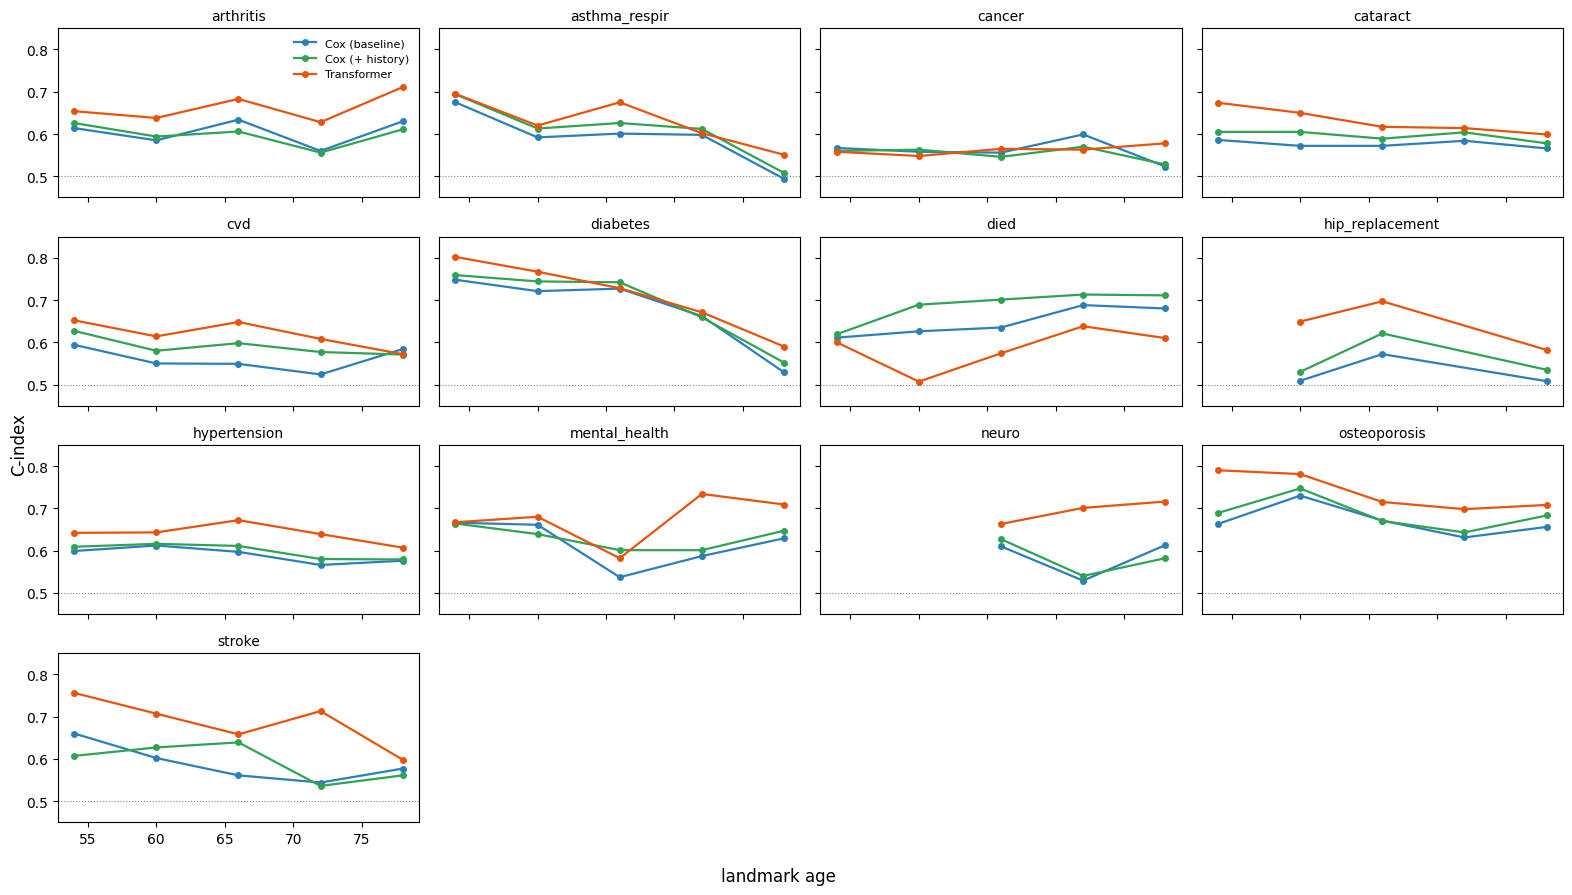

In [116]:
plot_comparison(sweep).show()